<a href="https://colab.research.google.com/github/mbaker21231/MicroII-Sandbox/blob/main/Computation_of_Equilibrium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Existence proof

Can we prove the existence of an equilibrium? Yes, by using Walras's law. We can normalize prices to fall on the unit simplex, so we have $\sum p=1$.

### The key mapping

This mapping plays a key role in a lot of things (game theory as well - construction of Lyapunov functions. It is (here $i$ indexes goods, not people):

$$
f_i(p)=\frac{p_i + \max(0, z_i(p))}{\sum (p_i +  \max(0, z_i(p))}
$$

Before using this to prove existence, let's try this out for the triple Cobb-Douglas economy where start with utility:
$$
U = x_1^\alpha x_2^\beta x_3^{1-\alpha-\beta}
$$
we have:

$$
x_1=\frac{\alpha I}{p_1},\quad x_2 = \frac{\beta I}{p_2},\quad x_3=\frac{(1-\alpha-\beta)I}{p_3}
$$

$$
I = p_1e_1 + p_2e_2 + p_3e_3
$$

### Question: do we have to worry about the number of agents in this economy?

What follows is a little code that employs this iteration scheme. So:

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

def simpmapper(pv = [1/3,1/3,1/3], alpha=1/2, beta=1/3, e1=1, e2=1, e3=1, maxits=20):

    iter = 1
    z1 = 1
    z2 = 1
    z3 = 1
    while (iter < maxits) & (sum((abs(z1), abs(z2), abs(z3))) > .001):
        I  = pv[0]*e1 + pv[1]*e2 + pv[2]*e3
        x1 = alpha*I/pv[0]
        x2 = beta*I/pv[1]
        x3 = (1-alpha-beta)*I/pv[2]

        z1 = x1 - e1
        z2 = x2 - e2
        z3 = x3 - e3

        print('Iteration ', iter)
        print('Prices         - p1:', round(pv[0], 2), ' p2:', round(pv[1], 2), 'p3:', round(pv[2], 2))
        print('Excess demands - z1:', round(z1, 2),    ' z2:', round(z2, 2)   , 'z3:', round(z3, 2))
        print('')

        denom = sum(pv) + np.max((0, z1)) + np.max((0, z2)) + np.max((0, z3))

        pv[0] = (pv[0] + np.max((0, z1))) / denom
        pv[1] = (pv[1] + np.max((0, z2))) / denom
        pv[2] = (pv[2] + np.max((0, z3))) / denom

        time.sleep(3)
        iter = iter + 1

In [3]:
simpmapper(e3=4)

Iteration  1
Prices         - p1: 0.33  p2: 0.33 p3: 0.33
Excess demands - z1: 2.0  z2: 1.0 z3: -3.0

Iteration  2
Prices         - p1: 0.58  p2: 0.33 p3: 0.08
Excess demands - z1: 0.07  z2: 0.25 z3: -1.5

Iteration  3
Prices         - p1: 0.5  p2: 0.44 p3: 0.06
Excess demands - z1: 0.2  z2: -0.1 z3: -0.86

Iteration  4
Prices         - p1: 0.58  p2: 0.37 p3: 0.05
Excess demands - z1: -0.0  z2: 0.05 z3: -0.33

Iteration  5
Prices         - p1: 0.55  p2: 0.4 p3: 0.05
Excess demands - z1: 0.04  z2: -0.04 z3: -0.17

Iteration  6
Prices         - p1: 0.57  p2: 0.38 p3: 0.05
Excess demands - z1: 0.0  z2: -0.0 z3: -0.04

Iteration  7
Prices         - p1: 0.57  p2: 0.38 p3: 0.05
Excess demands - z1: 0.0  z2: 0.0 z3: -0.02

Iteration  8
Prices         - p1: 0.57  p2: 0.38 p3: 0.05
Excess demands - z1: 0.0  z2: -0.0 z3: -0.01

Iteration  9
Prices         - p1: 0.57  p2: 0.38 p3: 0.05
Excess demands - z1: 0.0  z2: 0.0 z3: -0.01

Iteration  10
Prices         - p1: 0.57  p2: 0.38 p3: 0.05
Excess d

That's great, but uniqueness of equilibrium is generally hard to gaurantee! Here is an example of how this might not work out...

# Uniqueness of equilibrium?

This example comes from the work of Timothy Kehoe. Consider Kehoe's example with a CES function:

$$
u_i = a_1^i(x_1^{b_i}-1)/b_i + a_2^i(x_2^{b_i}-1)/b_i
$$

Let $\eta_i = 1/(1-b_i)$.

This gives demand functions (demand for good $j$ by consumer $i$):

$$
x_j^i(p_1,p_2) = \frac{(a_j^i)^{\eta_i}(p_1w^i_1+p_2w_2^i)}{p_j^{\eta_i}((a_1^i)^{\eta_i}p_1^{1-\eta_i}+(a_2^i)^{\eta_i}p_2^{1-\eta_i})}
$$

Kehoe shows there are multiple equilibria for the case in which we have: $b_1=b_2=-4$, so $\eta_1=\eta_2=.2$. Also, $a_1^1=a_2^2=1024$, while $a_2^1=a_1^2=1$, and $w_1^1=w_2^2=60$, and $w_1^2=w_2^1=5$. Let's just write up a routine and see how this goes...


Let's think about the demand for good 1, and adopt the normalization that $p_1+p_2=1$. Then:

$$
x_1^i(p_1,p_2) = \frac{(a_1^i)^{\eta_i}(p_1w^i_1+(1-p_1)w_2^i)}{p_1^{\eta_i}((a_1^i)^{\eta_i}p_1^{1-\eta_i}+(a_2^i)^{\eta_i}(1-p_1)^{1-\eta_i})}
$$

Now, according to Walras's law, we can think about everything in terms of this function.  So, let's actually do a little programming to get this all straight. We have:

In [4]:
def d1(p1, a1, a2, w1, w2, eta=.2):

    p2 = 1 - p1
    num = a1**eta*(p1*w1 + p2*w2)
    den = p1**eta*(a1**eta*p1**(1-eta) + a2**eta*p2**(1-eta))

    return num / den

def z1(p1, a11, a12, a21, a22, w11, w12, w21, w22, eta1, eta2):

    x1 = d1(p1, a11, a12, w11, w12, eta1)
    x2 = d1(p1, a21, a22, w21, w22, eta2)

    return x1 + x2 - w11 - w12

In [5]:
# Kehoe's example:

A11 = 1024
A12 = 5
A21 = 5
A22 = 1024
W11 = 60
W12 = 5
W21 = 5
W22 = 60
ET1 = .2
ET2 = .2

pr = np.arange(0.05,.99,.01)

zr = z1(pr, A11, A12, A21, A22, W11, W12, W21, W22, ET1, ET2)
x1r = d1(pr, A11, A12, W11, W12, ET1)
x2r = d1(pr, A21, A22, W21, W22, ET2)

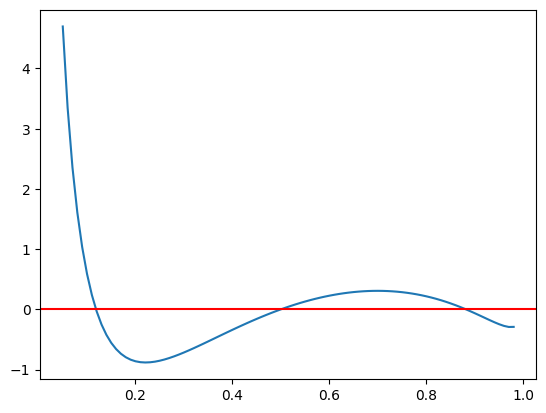

In [6]:
plt.plot(pr, zr)
plt.axhline(0, color='red')

But what do the demand functions look like here? Let's plot them out, noting the extreme income effects!

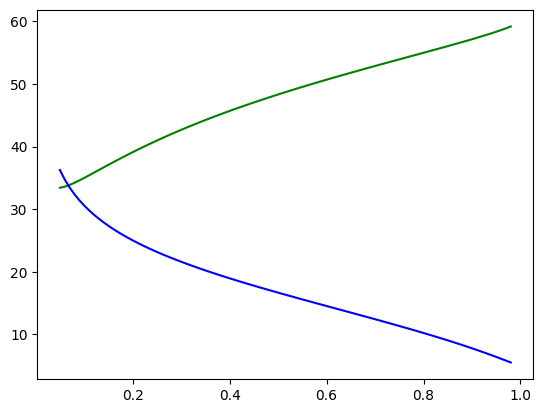

In [7]:
plt.plot(pr, x1r, color='green')
plt.plot(pr, x2r, color='blue')

# The Number of Equilibria

The trouble is due to income effects. Anyways, the index theorem says that

- "almost all" economies have an odd number of equilibria.
- A stable equilibrium should have $z'(p)<0$ at the equilibrium.

## Why?

Well, think about the Walrasian auctioneer. This person should typically increase the price of a good a little bit if the excess demand is positive, and decrease the price a little bit if the excess demand is negative.

So, we might have something like:

$$
\frac{dp}{dt} = \kappa z(p)
$$

In fact, let's look at our Kehoeian example and work with that a bit. We would have:

In [8]:
kappa = .05
p = .51
zrt = z1(p, A11, A12, A21, A22, W11, W12, W21, W22, ET1, ET2)
tol = .001
zs = []
ps = []
iter = 1
while (abs(zrt) > tol and iter < 300) or (iter == 1):
    ps.append(p)
    zs.append(zrt)

    zrt = z1(p, A11, A12, A21, A22, W11, W12, W21, W22, ET1, ET2)
    p = p + kappa*zrt
    iter += 1

Equilibrium: 0.881179446593381 0.0011128460834726184


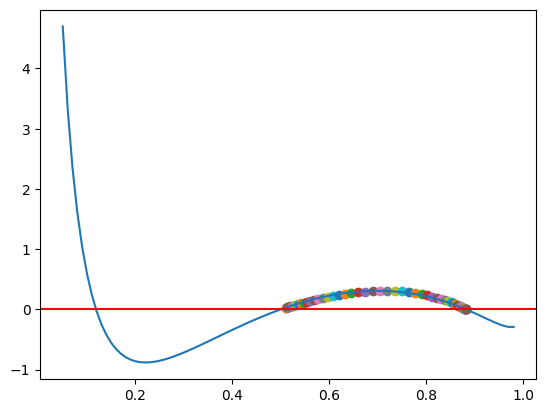

In [9]:
plt.plot(pr, zr)
plt.axhline(0, color='red')

for pt in zip(ps, zs):
    plt.scatter(pt[0], pt[1])

print('Equilibrium:', ps[-1], zs[-1])